# Logistic Regression

**Flow:** linear score → sigmoid probability → threshold → classification diagnostics.

Logistic regression models a probability. A threshold converts it to a class label; 0.5 is conventional, not mandatory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import r2_score, confusion_matrix
rng=np.random.default_rng(42)

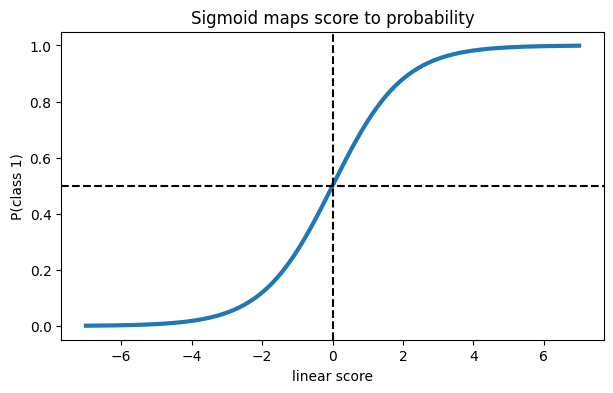

In [2]:
z=np.linspace(-7,7,300); plt.figure(figsize=(7,4)); plt.plot(z,1/(1+np.exp(-z)),lw=3); plt.axhline(.5,color='k',ls='--'); plt.axvline(0,color='k',ls='--'); plt.title('Sigmoid maps score to probability'); plt.xlabel('linear score'); plt.ylabel('P(class 1)'); plt.show()

scikit-learn LogisticRegression applies L2 regularization by default. Evaluate predicted labels with a confusion matrix and examine probabilities separately.

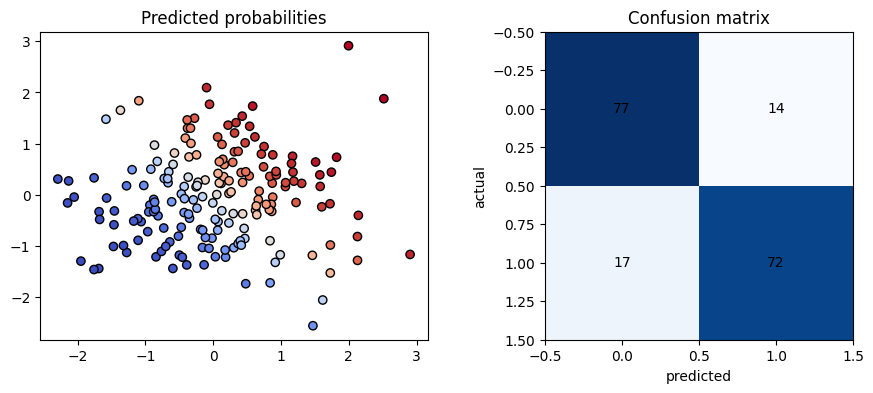

In [3]:
X=rng.normal(size=(180,2)); y=(X[:,0]+.8*X[:,1]+rng.normal(0,.7,180)>0).astype(int); p=Pipeline([('scale',StandardScaler()),('logit',LogisticRegression())]).fit(X,y); prob=p.predict_proba(X)[:,1]; cm=confusion_matrix(y,prob>=.5); fig,ax=plt.subplots(1,2,figsize=(11,4)); ax[0].scatter(X[:,0],X[:,1],c=prob,cmap='coolwarm',edgecolor='k'); ax[0].set(title='Predicted probabilities'); ax[1].imshow(cm,cmap='Blues');
for i in range(2):
 for j in range(2): ax[1].text(j,i,cm[i,j],ha='center',va='center')
ax[1].set(title='Confusion matrix',xlabel='predicted',ylabel='actual'); plt.show()